# 04 · Inference configuration — $\mathcal{F}(\mathcal{I})$

Three single-parameter choices caused score swings of 40–86 pp, all recoverable
from stored result files without re-running inference.


In [1]:
import nbtools as nb
from nbtools import (
    show_df, show_fig, show_md, show_tex,
    run_mod, run_live, heavy,
    REGEN, OUTPUTS_FINAL, OUTPUTS_DIR, PIPELINE_ROOT,
)
import pandas as pd
from IPython.display import display, HTML
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.1f}'.format)

# The 10 models evaluated in the paper (Table 2).
PAPER_MODELS = {
    'Claude Sonnet 4.6':   'claude-sonnet-4-6-cyberxpert',
    'GPT-5.4':             'gpt-5.4',
    'Gemma-4-31B':         'gemma-4-31B-it',
    'Qwen3.6-35B':         'Qwen3.6-35B-A3B',
    'Llama-3.3-70B':       'Llama-3.3-70B-Instruct',
    'GPT-OSS-20B':         'gpt-oss-20b',
    'Primus-Nemotron-70B': 'Llama-Primus-Nemotron-70B',
    'Primus-Merged-8B':    'Llama-Primus-Merged',
    'Foundation-Sec-8B':   'Foundation-Sec-8B-Instruct',
    'RedSage-Qwen3-8B':    'RedSage-Qwen3-8B-DPO',
}

print(f"Data root: {OUTPUTS_FINAL.name}/  — {'OK' if OUTPUTS_FINAL.exists() else 'MISSING'}")

Data root: outputs_final/  — OK


### F2(I): Token-budget filter — SecEval / GPT-5.4

SecEval specifies `max_new_tokens=5`. For GPT-5.4 via Azure this fell below the
API minimum, causing silent HTTP 400 failures on every call.
Both runs are stored: `gpt-5.4_final` (0.32%) and `gpt-5.4_seceval_rerun` (81.36%).


In [2]:
import json, pandas as pd
from IPython.display import display
from load_results import EVAL_RESULTS

orig_p  = EVAL_RESULTS / 'gpt-5.4_final'         / 'seceval_result.json'
fixed_p = EVAL_RESULTS / 'gpt-5.4_seceval_rerun'  / 'seceval_result.json'

orig_s  = json.loads(orig_p.read_text()).get('primary_score')  if orig_p.exists()  else None
fixed_s = json.loads(fixed_p.read_text()).get('primary_score') if fixed_p.exists() else None

if orig_s is not None and fixed_s is not None:
    f2i_df = pd.DataFrame([
        {'Condition': 'Original run  (max_new_tokens=5)', 'SecEval score (%)': orig_s,  'Δ vs corrected (pp)': None},
        {'Condition': 'Corrected budget',                  'SecEval score (%)': fixed_s, 'Δ vs corrected (pp)': fixed_s - orig_s},
    ])
    display(f2i_df.style
            .hide(axis='index')
            .format({'SecEval score (%)': '{:.1f}%', 'Δ vs corrected (pp)': lambda v: f'+{v:.1f}' if v is not None else '—'})
            .background_gradient(subset=['SecEval score (%)'], cmap='Blues', vmin=0, vmax=100)
            .map(lambda v: 'color:green;font-weight:bold' if isinstance(v, float) and v > 50 else '', subset=['Δ vs corrected (pp)'])
            .set_caption('F2(I): Token-budget filter — GPT-5.4 SecEval. Original 5-token budget caused silent HTTP 400 failures.'))
else:
    print(f"[missing] orig={orig_p.exists()}  fixed={fixed_p.exists()}")

Condition,SecEval score (%),Δ vs corrected (pp)
Original run (max_new_tokens=5),0.3%,+nan
Corrected budget,81.4%,+81.0


### F1(I): Stop-sequence mismatch — RedSage-Bench / Qwen3.6-35B

Official `stop=["\n"]` fires at the first newline of Qwen3's `<think>` block,
before any answer token. Our harness drops the stop; the corrected scores are stored in the repository.


In [3]:
import json, pandas as pd
from IPython.display import display
from load_results import load_all_scores

scores = load_all_scores(OUTPUTS_FINAL)
qwen_dir = 'Qwen3.6-35B-A3B'
redsage_tasks = sorted(t for t in scores.get(qwen_dir, {}) if t.startswith('redsage_'))
if redsage_tasks:
    task_rows = [{'Task': t, 'Score (%)': scores[qwen_dir][t]}
                 for t in redsage_tasks if scores[qwen_dir].get(t) is not None]
    vals = [r['Score (%)'] for r in task_rows]
    avg = sum(vals) / len(vals)
    task_rows.append({'Task': 'Average — our harness (no stop sequence)', 'Score (%)': avg})
    f1i_df = pd.DataFrame(task_rows)
    display(f1i_df.style
            .hide(axis='index')
            .format({'Score (%)': '{:.1f}%'})
            .background_gradient(subset=['Score (%)'], cmap='Blues', vmin=0, vmax=100)
            .apply(lambda s: ['font-weight:bold;border-top:2px solid #aaa' if i == len(s)-1 else '' for i in range(len(s))], subset=['Score (%)'])
            .set_caption('F1(I): Qwen3.6-35B-A3B RedSage scores — our harness drops the official stop=["\\n"] that fires inside the <think> block.'))
else:
    print(f"[missing] {qwen_dir} not in outputs_final/")

Task,Score (%)
redsage_cli,88.8%
redsage_frameworks,83.7%
redsage_generals,85.4%
redsage_kali,81.4%
redsage_skills,90.1%
Average — our harness (no stop sequence),85.9%


### F3(I): Temperature drift — CyberMetric / Primus-Merged

CyberMetric's paper prescribes T=1.0; the released evaluator uses T=0.
Both runs stored: `cybermetric_paper_result.json` (T=1.0) vs
`cybermetric_result.json` (T=0). Primus-Merged: **57.2% → 17.2%, −40 pp**.


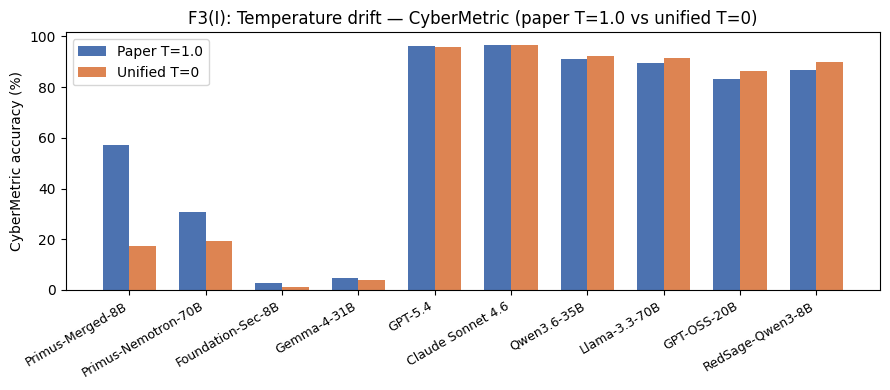

/tmp/ipykernel_1510815/2085954066.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(temp_df.style


Model,Paper T=1.0 (%),Unified T=0 (%),Δ (pp)
Primus-Merged-8B,57.2%,17.2%,-40.0
Primus-Nemotron-70B,30.6%,19.2%,-11.4
Foundation-Sec-8B,2.8%,1.0%,-1.8
Gemma-4-31B,4.8%,4.0%,-0.8
GPT-5.4,96.2%,96.0%,-0.2
Claude Sonnet 4.6,96.6%,96.8%,+0.2
Qwen3.6-35B,91.0%,92.2%,+1.2
Llama-3.3-70B,89.6%,91.6%,+2.0
GPT-OSS-20B,83.4%,86.4%,+3.0
RedSage-Qwen3-8B,86.8%,89.8%,+3.0


In [4]:
from load_results import load_all_scores

scores = load_all_scores(OUTPUTS_FINAL)
rows = []
for label, dir_name in PAPER_MODELS.items():
    p = scores.get(dir_name, {}).get('cybermetric_paper')
    u = scores.get(dir_name, {}).get('cybermetric')
    if p is not None and u is not None:
        rows.append({'Model': label,
                     'Paper T=1.0 (%)': round(p, 1),
                     'Unified T=0 (%)': round(u, 1),
                     'Δ (pp)':          round(u - p, 1)})

temp_df = pd.DataFrame(rows).sort_values('Δ (pp)').reset_index(drop=True)
import matplotlib.pyplot as plt, numpy as np
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(temp_df)); w = 0.35
ax.bar(x - w/2, temp_df['Paper T=1.0 (%)'].values, w, label='Paper T=1.0', color='#4C72B0')
ax.bar(x + w/2, temp_df['Unified T=0 (%)'].values, w, label='Unified T=0', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(temp_df['Model'].values, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('CyberMetric accuracy (%)')
ax.set_title('F3(I): Temperature drift — CyberMetric (paper T=1.0 vs unified T=0)')
ax.legend(); plt.tight_layout(); plt.show()
display(temp_df.style
        .hide(axis='index')
        .format({'Paper T=1.0 (%)': '{:.1f}%', 'Unified T=0 (%)': '{:.1f}%', 'Δ (pp)': '{:+.1f}'})
        .background_gradient(subset=['Paper T=1.0 (%)', 'Unified T=0 (%)'], cmap='Blues', vmin=0, vmax=100)
        .applymap(lambda v: 'color:red;font-weight:bold' if isinstance(v,(int,float)) and v <= -10 else '', subset=['Δ (pp)'])
        .set_caption('F3(I): Temperature drift — paper T=1.0 vs unified T=0. Red = gap ≥10pp.'))